# LABORATORIO DE FÍSICA COMPUTACIONAL - 2º DTIE MATEMÁTICAS Y FÍSICA

<p style="text-indent: 0em; text-align: justify;">La física computacional emplea algoritmos y potencia de cálculo para resolver ecuaciones matemáticas complejas que describen el comportamiento de la naturaleza.

<p style="text-indent: 0em; text-align: justify;">Es indispensable para predecir fenómenos que son imposibles de recrear en laboratorios o de resolver manualmente, como la evolución de galaxias o el clima.

<p style="text-indent: 0em; text-align: justify;">Funciona como un laboratorio virtual, permitiendo testear teorías y diseñar tecnologías avanzadas de forma rápida, segura y extremadamente precisa. Para trabajar en esta asignatura utilizaremos Python como lenguaje de programación. Los ordenadores nos permiten resovler numéricamente problemas que de otra forma no podríamos resolver.

### Ejemplo: aproximación computacional a la integral
<p style="text-indent: 0em; text-align: justify;">Como ejemplo ilustrativo se pide aproximar la integral de Fresnel, que aparece de forma experimental en física óptica, por ejemplo.

$$I = \int_0^\pi \sin (x^2) dx$$

In [34]:
import math

def f(x):
    return math.sin(pow(x, 2))

intervalos = 1000
limite_inf = 0
limite_sup = math.pi

paso = (limite_sup - limite_inf) / intervalos

posicion_actual = limite_inf
valor_integral = 0

for i in range(intervalos):
    valor_integral += f(posicion_actual) * paso
    posicion_actual += paso

print(f"Valor final de la integral entre a = {limite_inf} y b = {limite_sup} de la función f: {valor_integral}")
    
    

Valor final de la integral entre a = 0 y b = 3.141592653589793 de la función f: 0.77332296340999


## Problema 1: El muelle simple. Aplicación de las leyes de Newton.

<p style="text-indent: 0em; text-align: justify;">Supongamos una particula de masa $m$ que se mueve unidimensionalmente a lo largo del eje $x$. Su posición en función del tiempo viene dada por la función $x(t)$. Supongamos que la particula está bajo los efectos de un muelle Newtoniano de constante $k$. Entonces la función posición deberá cumplir la EDO del muelle:

$$m\frac{d^2 x}{dt}(t) = -k x(t) \iff mx''(t) = -kx(t)$$

<p style="text-indent: 0em; text-align: justify;">La partícula se movera entre un tiempo inicial $t_i = t_0$ y un tiempo final $t_f = t_N$. Como solo podemos computar conjuntos discretos, estudiaremos la función posició en el intervalo $\Delta t = t_f - t_i$ dividido en $N$ partes equiespaciadas 
$t_0, t_1, t_2, ..., t_N$. Es decir, no podemos determinar la función $x(t)$ completa, pero si podemos determinar su valor en los $N$ intervalos equiespaciados de $\Delta t$. 

<p style="text-indent: 0em; text-align: justify;">Por la ecuación del muelle y escribiendo la aceleración como:
$$x''(t) = \lim_{h \to 0} \frac{x(t+h)-2x(t) +x(t-h))}{h^2}$$

<p style="text-indent: 0em; text-align: justify;">Conseguimos una expresión computacional para la aceleración. Así, en la ecuación del muelle:
    
$$mx''(t_i) = -kx(t_i)$$
<p style="text-indent: 0em; text-align: justify;">Sin embargo no podemos utilizar la definición de la aceleración de forma exacta (los ordenadores no pueden computar límties de forma exacta) pero sí podemos aproximarla como:
    
$$x''(t_i) \approx \frac{x(t_{i+1}) - 2x(t_i) + x(t_{i+1})}{\Delta t^2}$$
<p style="text-indent: 0em; text-align: justify;">Entonces, en la ecuación del muelle:
    
$$m \frac{x(t_{i+1}) - 2x(t_i) + x(t_{i+1})}{\Delta t^2} \approx -kx(t_i)$$
<p style="text-indent: 0em; text-align: justify;">Que se corresponde con $N-1$ ecuaciones, una por cada $t_i$ (porque no puedo aplicar la ecuación en $t_0$ ni en $t_N$ porque no puedo aplicar la ecuación en estos dos instantes de tiempo: solo puedo aplicar la fórmula de la aproximación en el interior del $\Delta t$. Si además denotamos por simplicidad $x(t_i) := x_i$, el problema se reduce a resolver el sistema:

$$
\begin{equation}
\begin{cases}
x_{i+1} - 2x_i + x_{i-1} = -\frac{k}{m}\Delta t^2 x_i \iff x_{i+1} + \left(\frac{k}{m} \Delta t^2 - 2\right)x_i + x_{i-1} = 0\}_{i=1,\dots,N-1} 
\end{cases}
\end{equation}
$$
El problema para este sistema es que tenemos $N+1$ incógnitas $t_0, t_1, \dots, t_N$ y tan solo $N-1$ ecuaciones. Por suerte de la EDO:
$$mx''(t) = -kx(t) \implies x(t) = A\cos(\omega t) \pm B\sin(\omega t)$$
No puedo resolver el problema solo con esta EDO, sino que tenemos que establecer las condiciones iniciales para el problema.
$$
\begin{equation}
\begin{cases}
x(t_0 = 0) = x_0 \\
x'(t_0 = 0) = v_0
\end{cases}
\end{equation}
$$
Con estas condiciones iniciales, automáticamente reducimos las incógnitas de $N+1$ a $N$ (porque conocemos el valor de $x_0$). Todavía necesito una ecuación extra para reducir las incógnitas a $N-1$ (que es el número de ecuaciones que tengo). Con las condiciones iniciales, en particular con $v_0$. Por la definición de derivada (y en particular de velocidad):  
$$v_0 \approx \frac{x_1 - x_0}{\Delta t}$$
Si $\Delta t$ es suficientemente pequeña, podemos modelar la poisición como:
$$x(t+h) = x(t) + x'(t)h + \frac{1}{2!}x''(t)h^2 + \cdots$$
En particular si centramos el desarrollo en $t_0$ con $h = \Delta t$ tendré $$ x_1 = x_0 + v_0 \Delta t + \frac{1}{2}x''(0)\Delta t ^2 = x_0 + v_0 \Delta t - \frac{1}{2}\frac{kx_0}{m}\Delta t ^2 = x_0 + v_0\Delta t - \frac{k}{2m}x_0\Delta t^2$$
Que nos da la ecuación que faltaba para conseguir las $N+1$ ecuaciones que resuelven el problema. Entonces, el problema consiste en resolver:

### Implementación en Python

In [35]:
# VALORES INICIALES DEL PROBLEMA
k = 1 # N / m
masa = 1 # g

tinicial = 0  # sec
xinicial = 10 #cm
vinicial = 0  # m/s

tfinal = 18
N = 100

delta = (tfinal - tinicial) / N

# Inicialización para los dos primeros valores
x0 = xinicial
v0 = vinicial

# x1 mediante Taylor: x(t+h) ≈ x(t) + h*v(t) + (h^2/2)*a(t)
x1 = x0 + v0 * delta - (k / (2 * masa)) * x0 * (delta**2)

output = [x0, x1]

# Usamos N-1 porque ya tenemos 2 puntos y queremos llegar al paso N
for i in range(1, N):
    xsiguiente = (2 - (k / masa) * (delta**2)) * output[i] - output[i-1]
    output.append(xsiguiente)

# Salida (limitada para no inundar la consola)
for i in range(len(output)):
    print(f"{i}: {output[i]}")


%matplotlib inline



0: 10
1: 9.838
2: 9.357248799999997
3: 8.573322738879996
4: 7.511621021020282
5: 6.206542782079511
6: 4.700372556999364
7: 3.0419102610724362
8: 1.2848900726867623
9: -0.5137605540539627
10: -2.2957653388433394
11: -4.003387326654192
12: -5.581299565081448
13: -6.978377697600065
14: -8.14935639271644
15: -9.056295940708802
16: -9.6698115002222
17: -9.9700251671284
18: -9.947210018619637
19: -9.602105265507598
20: -8.945892301793114
21: -7.999832427500534
22: -6.7945779825569375
23: -5.369179210978496
24: -3.7698190329643513
25: -2.0483167182821616
26: -0.26044894192762946
27: 1.5358573801453579
28: 3.2824019231016357
29: 4.92259664374942
30: 6.403299233139723
31: 7.676534927376299
32: 8.701050889965883
33: 9.443652803720571
34: 9.880280366634713
35: 9.996786845669892
36: 9.789397430905366
37: 9.264831539379507
38: 8.440085105977753
39: 7.341879915142318
40: 6.0057978150562725
41: 4.4751278657624045
42: 2.799463773617834
43: 1.0330970552080458
44: -0.7667420077904832
45: -2.541738629736

Podemos graficar la solución:

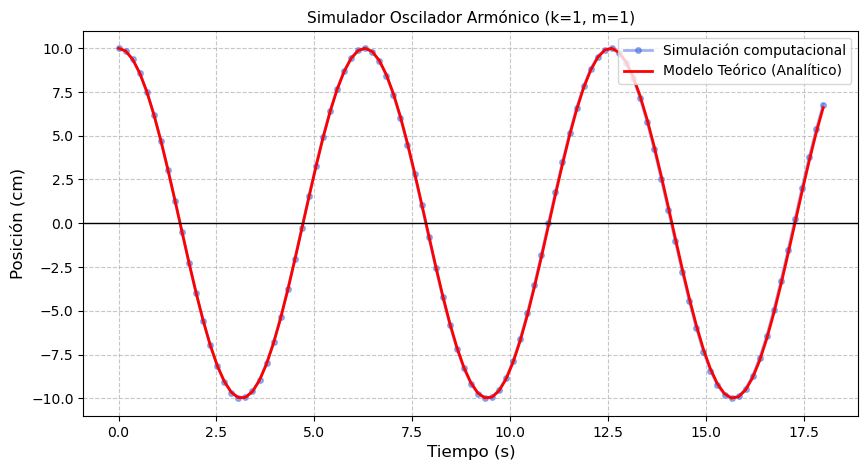

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Cálculo de la frecuencia angular teórica
omega = np.sqrt(k / masa)

# Definición del tiempo
tiempo = np.arange(len(output)) * delta

# Configuración de la gráfica
plt.figure(figsize=(10, 5))

# 1. Simulación (Puntos azules)
plt.plot(tiempo, output, label='Simulación computacional', color='royalblue', linewidth=2, marker='o', markersize=4, alpha=0.5)

# 2. MODELO TEÓRICO (Línea roja)
# Usamos la fórmula: x(t) = xinicial * cos(omega * t)
x_teorica = xinicial * np.cos(omega * tiempo)
plt.plot(tiempo, x_teorica, label='Modelo Teórico (Analítico)', 
         color="red", linewidth=2, linestyle='-')

# Estética de la gráfica
plt.title(f"Simulador Oscilador Armónico (k={k}, m={masa})", fontsize=11)
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Posición (cm)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='black', linewidth=1) 
plt.legend()

plt.show()

Podemos incluso determinar el periodo del péndulo para así no calcular ningún dato inecesario (hacer cálculos consume recursos). Así si $t_f \gt T$ solo será necesario calcular las iteradas hasta $T$. Otra de las mejoras posibles es calcular $N$ en función de una resolución dada, que no sea simplemente un parámetro fijo.

In [4]:
import math

# VALORES INICIALES DEL PROBLEMA
k = 1 # N / m
masa = 0.01 # kg

tinicial = 0  # sec
xinicial = 10 #cm
vinicial = 0  # m/s

tfinal = 100

# Para calcular N en función de la resolución dada
puntos_por_segundo = 10

# Calculo el periodo del sistema 
periodo = 2 * math.pi * math.sqrt(masa / k)
tiempo_optimo = min(tfinal - tinicial, periodo / 2) # Periodo entre dos porque un periodo es "ir y venir"
N = max(int(puntos_por_segundo * tiempo_optimo), 2)
delta = tiempo_optimo / N 

# Inicialización para los dos primeros valores
x0 = xinicial
v0 = vinicial

# x1 mediante Taylor: x(t+h) ≈ x(t) + h*v(t) + (h^2/2)*a(t)
x1 = x0 + v0 * delta - (k / (2 * masa)) * x0 * (delta**2)

output = [x0, x1]

# Usamos N-1 porque ya tenemos 2 puntos y queremos llegar al paso N
c = (k / masa) * (delta**2)
for i in range(1, N):
    xsiguiente = (2 - c) * output[i] - output[i-1]
    output.append(xsiguiente)

# Salida (limitada para no inundar la consola)
for i in range(len(output)):
    print(f"{i}: {output[i]}")


0: 10
1: 4.516886443839246
2: -5.919547370692251
3: -9.864471098308062


### Ejercicio: Demostración de la segunda derivada mediante límites

<p style="text-indent: 0em; text-align: justify;">Problema para casa (para el doble grado). Sea $x: I \subseteq \mathbb{R} \to \mathbb{R}$ dos veces diferenciable (derivable), entonces:

$$x''(t) = \lim_{h \to 0} \frac{x(t+h) - 2x(t) + x(t-h)}{h^2} \quad \forall t \in \mathring{I}$$


<p style="text-indent: 0em; text-align: justify;">La prueba es sencilla con la regla de L'Hôpital. Para un $t \in \mathring{I}$:

$$
\begin{aligned}
& \lim_{h \to 0} h^{-2} (x(t+h) - 2x(t) + x(t-h)) \\ \\
= & \lim_{h \to 0}    \frac{\frac{d}{d h} [x(t+h) - 2x(t) + x(t-h)]}{\frac{d}{d h} h^2} \\\\
= & \lim_{h \to 0}  \frac{x'(t+h) - x'(t-h)}{2h} \\\\
= & \lim_{h \to 0} (2h)^{-1} (x'(t+h) - x'(t) + \underbrace{x'(t) - x'(t-h)}_{=0}) \\\\
= & \frac{1}{2} \lim_{h \to 0} \left( \frac{x'(t+h) - x'(t)}{h} + \frac{x'(t) - x'(t-h)}{h} \right) \\\\
\overset{\text{def}}{=} & \frac{1}{2} (x''(t) + \lim_{h \to 0} \frac{x'(t) - x'(t-h)}{h}) \overset{\text{*}}{=} \frac{1}{2} [2x''(t)] = x''(t)
\end{aligned}
$$

(*) Cálculo auxiliar (es la derivada con paso inferior en vez de superior), donde tomamos $k := -h$:

$$
\begin{aligned}
\lim_{h \to 0} & \frac{x'(t) - x'(t-h)}{h} \\
= \lim_{h \to 0} & \frac{-[x'(t-h) - x'(t)]}{h} \\
\text{hacemos } k = -h \implies & \lim_{k \to 0} \frac{x'(t+k) - x'(t)}{k} \\
\overset{\text{def}}{=} & x''(t)
\end{aligned}
$$

$\square$

## Problema 2: Movimiento unidimensional bajo una fuerza arbitraria
<p style="text-indent: 0em; text-align: justify;">¿Y si la fuerza que actúa sobre la particula no es la fuerza dada por la Ley de Hook? Supongamos una particula que se mueve en una dimensión bajo el efecto de una fuerza arbitraria que denotaremos por $F$.
    
$$m\frac{d^2x(t)}{dt^2} = F(x)$$
<p style="text-indent: 0em; text-align: justify;">Podemos describir esta ecuacion como:
    
$$F(x) = -\frac{dV(x)}{dx}$$
<p style="text-indent: 0em; text-align: justify;">Donde el potencial se entiende como la energía que almacena un cuerpo por estar en un campo de fuerzas. 

<p style="text-indent: 0em; text-align: justify;">Este potencial verificará la Ley de Conservación de la energía: una ley fundamental de la física que dice que la energía ni se crea ni se destruye. En un sistema aislado, la cantidad de energía permanece constante a lo largo del tiempo. 

$$\frac{1}{2} m \left(\frac{dx(t)}{dt}\right)^2 + V(x(t)) = constante = k$$
<p style="text-indent: 0em; text-align: justify;">Que desde las Ecuaciones diferenciales se entiende como la integral primera:
    
$$\frac{1}{2} m \left(x'(t)\right)^2 + V(x(t)) = constante = k$$

> <p style="text-indent: 0em; text-align: justify;">Dada la EDO $$x'(t) = f(x, t)$$ una integral primera es una función $$E:\Omega \subset \mathbb{R}^2 \longrightarrow \mathbb{R}$$ de forma que para cualquier solución de la EDO $$x: I \subset  \mathbb{R} \longrightarrow \mathbb{R}$$verifica:$$E(x(t), t) = E = \text{ constante  } \forall t \in I$$

<p style="text-indent: 0em; text-align: justify;">Donde la velocidad viene dada (numéricamente) como:
$$x'(t_i) \approx \frac{x(t_{i+1}) - x_i}{\Delta t}$$

### Ejercicio: ¿Se cumple la conservación de la energía para el muelle unidimensional?


<p style="text-indent: 0em; text-align: justify;">Para demostrar que la energía se conserva, definimos la Energía Mecánica Total ($E$) como la suma de la Energía Cinética ($T$) y la Energía Potencial ($V$):
$$E(t) = T(t) + V(t) = \frac{1}{2} m v(t)^2 + \frac{1}{2} k x(t)^2$$
<p style="text-indent: 0em; text-align: justify;">Para probar que $E(T) = E$ es una constante, su derivada respecto al tiempo debe ser igual a cero:
$$\frac{dE}{dt} = m \cdot v(t) \cdot \frac{dv(t)}{dt} + k \cdot x(t) \cdot \frac{dx(t)}{dt} = v(t) \cdot \left[m\cdot \frac{dv(t)}{dt} + k \cdot x(t) \right] v(t) \cdot \left[m\cdot a(t) + k \cdot x(t) \right]$$
<p style="text-indent: 0em; text-align: justify;">Además por la segunda Ley de Newton:
$$m \cdot a(t) = -k \cdot x(t) \implies m \cdot a(t) + k \cdot x(t) = 0$$
<p style="text-indent: 0em; text-align: justify;">Sustituyendo esta igualdad en nuestra derivada:
$$\frac{dE}{dt} = 0$$
<p style="text-indent: 0em; text-align: justify;">Como la variación de la energía respecto al tiempo es nula, concluimos que la energía total es constante:
$$E_{total} = \text{constante}$$

### Algoritmo de Euler
<p style="text-indent: 0em; text-align: justify;">Podemos plantear un algoritmo diferente para comprobar (computacionalmente) que la Energía se conserva. Utilizaremos un algoritmo nuevo para para calcular simultáneamente la posición y la velocidad

<p style="text-indent: 0em; text-align: justify;">Supongamos una partícula que se mueve bajo la acción de una fuerza que depende únicamente de la posición de la partícula. La 2ª Ley de Newton se traduce directamente en la siguiente Ecuación ordinaria de segundo grado. $$m\ddot{x} = F(x)$$Con F(x) una fuerza conocida. El objetivo es traducir el problema para no tener que calcular segundas derivadas. Consideremos la reducción del sistema:
$$\begin{cases}v(t) = \dot{x}(t)\\a(t) = \dot{v}(t) = \ddot{x}(t) = \frac{1}{m} F(x(t))\end{cases}$$

<p style="text-indent: 0em; text-align: justify;">Donde ahora las incógnitas son $\{x(t), v(t)\}$ (hemos introducido una nueva incógnita para simplificar el problema)

> <p style="text-indent: 0em; text-align: justify;">Imaginemos que tuviéramos una ecuación diferencial de orden $n$ en lugar de orden $2$. El método estándar es transformar la EDO original en un sistema de $n$ ecuaciones, todas ellas de primer orden.

<p style="text-indent: 0em; text-align: justify;">Como en el planteamiento del problema del muelle, trabajaremos con una partición de puntos $$\{t_i = t_0 < t_1 < t_2 < \dots < t_{N-1} < t_N = t_f\}$$

<p style="text-indent: 0em; text-align: justify;">Que no tiene necesariamente que ser homogénea. Si aplicamos el Teorema del valor medio, sabemos que para cada $i$:

$$x(t_{i+1}) - x(t_i) = \dot{x}(\xi_i) (t_{i+1} - t_i)$$


$$v(t_{i+1}) - v(t_i) = \dot{v}(\eta_i) (t_{i+1} - t_i)$$

<p style="text-indent: 0em; text-align: justify;">Donde $\eta_i$ y $\xi_i$ son puntos intermedios $$t_{i} < \xi_i, \eta_i < t_{i+1}$$

<p style="text-indent: 0em; text-align: justify;">Para el **Algoritmo de Euler** tomaremos $$\boxed{\xi_i = \eta_i = t_i}$$

<p style="text-indent: 0em; text-align: justify;">Con esta aproximación :

$$\begin{cases}\dot{x}(t) = v(t)\\v'(t) = \frac{1}{m}F(x(t))\end{cases} \iff \begin{cases}x_{i+1} = x_i  + v_i\Delta t\\
v_{i+1} = v_i + \frac{1}{m}F(x_i)\Delta t\end{cases}$$

In [5]:
# VALORES INICIALES DEL PROBLEMA
k = 1 # N / m
masa = 0.010 # g

tinicial = 0  # sec
xinicial = 10 #cm
vinicial = 0  # m/s

tfinal = 2
N = 100

delta = (tfinal - tinicial) / N

x0 = xinicial
v0 = vinicial

In [6]:
output_x = [x0]
output_v = [v0]

def fuerza(posicion):
    return - k * posicion
    
for i in range(N):
    # 1. a = F/m
    aceleracion = fuerza(output_x[i]) / masa
    
    # 2. xi+1 = xi + vi * delta
    xsiguiente = output_x[i] + output_v[i] * delta
    
    # 3. vi+1 = vi + (F/m) * delta  
    vsiguiente = output_v[i] + aceleracion * delta
    
    output_x.append(xsiguiente)
    output_v.append(vsiguiente)

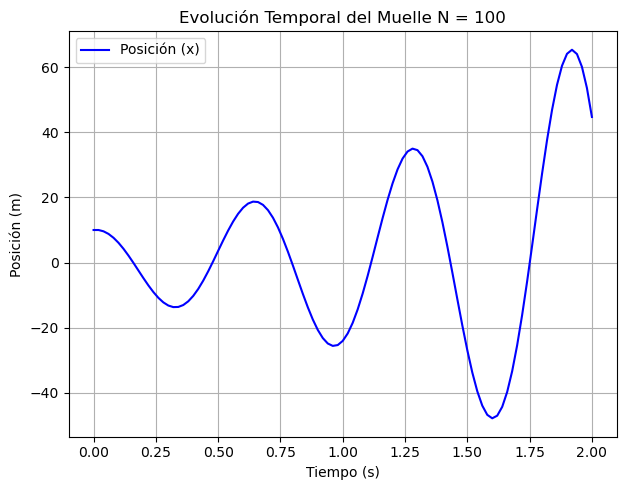

In [7]:
# Creamos un array de tiempo para el eje X de las gráficas
tiempo = np.linspace(tinicial, tfinal, len(output_x))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(tiempo, output_x, label='Posición (x)', color='blue')
plt.title(f"Evolución Temporal del Muelle N = {N}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición (m)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="text-indent: 0em; text-align: justify;">Es muy interesante cómo ver como la amplitud no se mantiene constante. El algoritmo de Euler es mucho peor que el de la derivada segunda para el mismo coste de cálculo. El problema es el mismo que el del algoritmo de la derivada segunda pero con $N=100$ vemos una amplificación total de la amplitud. Si tomamos $N = 10000$ los errores se refinan.

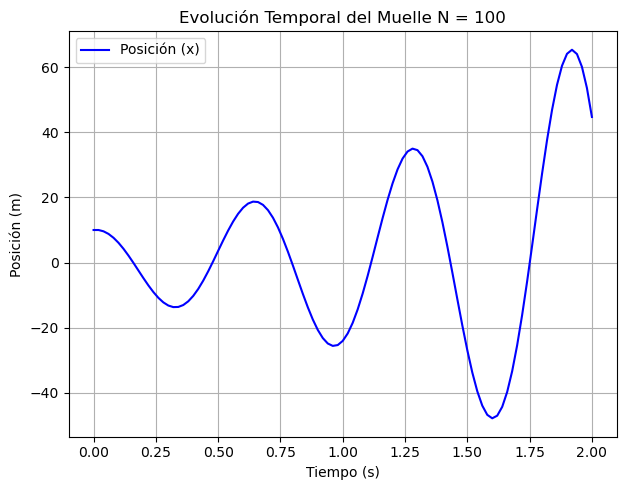

In [8]:
delta = (tfinal - tinicial) / N


output_x = [x0]
output_v = [v0]

for i in range(N):
    aceleracion = fuerza(output_x[i]) / masa
    xsiguiente = output_x[i] + output_v[i] * delta
    vsiguiente = output_v[i] + aceleracion * delta
    output_x.append(xsiguiente)
    output_v.append(vsiguiente)

tiempo = np.linspace(tinicial, tfinal, len(output_x))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tiempo, output_x, label='Posición (x)', color='blue')
plt.title(f"Evolución Temporal del Muelle N = {N}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición (m)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<p style="text-indent: 0em; text-align: justify;">El Algoritmo de Euler tiene más itneres teórico que interés práctico. Necesita un coste de cálculo descomunal.

### Modificaciones del método de Euler.

#### Elección del extremo derecho

<p style="text-indent: 0em; text-align: justify;">Si en lugar de aproximar por el Algoritmo de Euler:
$$\xi_i = \eta_i = t_i$$
<p style="text-indent: 0em; text-align: justify;">Aproximamos los valores intermedios del Teorema del Valor Medio por $$\xi_i = \eta_i = t_{i+1}$$
<p style="text-indent: 0em; text-align: justify;">A la hora de programarlo, es mucho más difícil: no puedo sacar $x_{i+1}$ sin tener $v_{i+1}$, pero no puedo tener $v_{i+1}$ sin tener $F(x_{i+1})$


#### Elección de un extremo izquierdo y un extremo derecho (Algoritmo de Euler modificado)

<p style="text-indent: 0em; text-align: justify;">Tomemos, por ejemplo:
$$\boxed{\xi_i = t_{i+1}\text{   ;   }\eta_i = t_{i}} $$
Entonces las ecuaciones computacionales serán:

$$\begin{cases}x_{i+1} = x_i  + v_{i+1}\Delta t\\
v_{i+1} = v_i + \frac{1}{m}F(x_i)\Delta t\end{cases}$$
<p style="text-indent: 0em; text-align: justify;">Y empezando por la segunda ecuación, podemos calcular computacionalmente las posiciones y velocidades

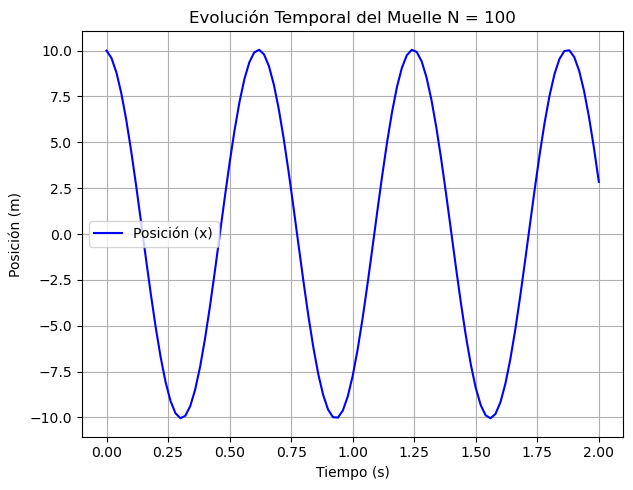

In [9]:
delta = (tfinal - tinicial) / N


output_x = [x0]
output_v = [v0]

for i in range(N):
    # 1. Calculamos la aceleración en el punto actual x[i]
    aceleracion = fuerza(output_x[i]) / masa
    
    # 2. ACTUALIZO PRIMERO LA VELOCIDAD (v_{i+1})
    # v_{i+1} = v_i + a * delta
    vsiguiente = output_v[i] + aceleracion * delta
    
    # 3. ACTUALIZAMOS LA POSICIÓN USANDO LA VELOCIDAD RECIÉN CALCULADA (v_{i+1})
    # x_{i+1} = x_i + v_{i+1} * delta
    xsiguiente = output_x[i] + vsiguiente * delta
    
    output_x.append(xsiguiente)
    output_v.append(vsiguiente)

tiempo = np.linspace(tinicial, tfinal, len(output_x))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(tiempo, output_x, label='Posición (x)', color='blue')
plt.title(f"Evolución Temporal del Muelle N = {N}")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición (m)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comparación computacional de los métodos de Euler

<p style="text-indent: 0em; text-align: justify;">Podemos programar un código que muestre las diferencias entre los distintos modelos del Algoritmo de Euler. Para este propósito, compararemos el algoritmo de Euler tradicional con el algoritmo de Euler modificado (elección de un extremo izquierdo y uno derecho).



In [24]:
def algoritmo_euler(tinicial, tfinal, N, x0, v0):
    delta = (tfinal - tinicial) / N

    output_x = [x0]
    output_v = [v0]
    
    for i in range(N):
        aceleracion = fuerza(output_x[i]) / masa
        xsiguiente = output_x[i] + output_v[i] * delta
        vsiguiente = output_v[i] + aceleracion * delta
        output_x.append(xsiguiente)
        output_v.append(vsiguiente)

    return output_x, output_v

def algoritmo_euler_modificado(tinicial, tfinal, N, x0, v0):
    delta = (tfinal - tinicial) / N


    output_x = [x0]
    output_v = [v0]
    
    for i in range(N):
        aceleracion = fuerza(output_x[i]) / masa
        vsiguiente = output_v[i] + aceleracion * delta
        xsiguiente = output_x[i] + vsiguiente * delta
        
        output_x.append(xsiguiente)
        output_v.append(vsiguiente)

    return output_x, output_v

In [11]:
def graficar_algoritmos(N):
    """Mismas condiciones inciales para un mismo número de operaciones N"""
    x_euler, v_euler = algoritmo_euler(tinicial, tfinal, N, xinicial, vinicial)
    x_euler_mod, v_euler_mod = algoritmo_euler_modificado(tinicial, tfinal, N, xinicial, vinicial)

    tiempo = np.linspace(tinicial, tfinal, len(x_euler))
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(tiempo, x_euler, label='Algoritmo de Euler simple', color='red')
    plt.plot(tiempo, x_euler_mod, label='Algoritmo de Euler modificado', color='blue')
    
    plt.title(f"Comparación de Algoritmos (N = {N} pasos)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Posición (m)")
    plt.axhline(0, color='black', lw=1) # Línea de equilibrio
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()

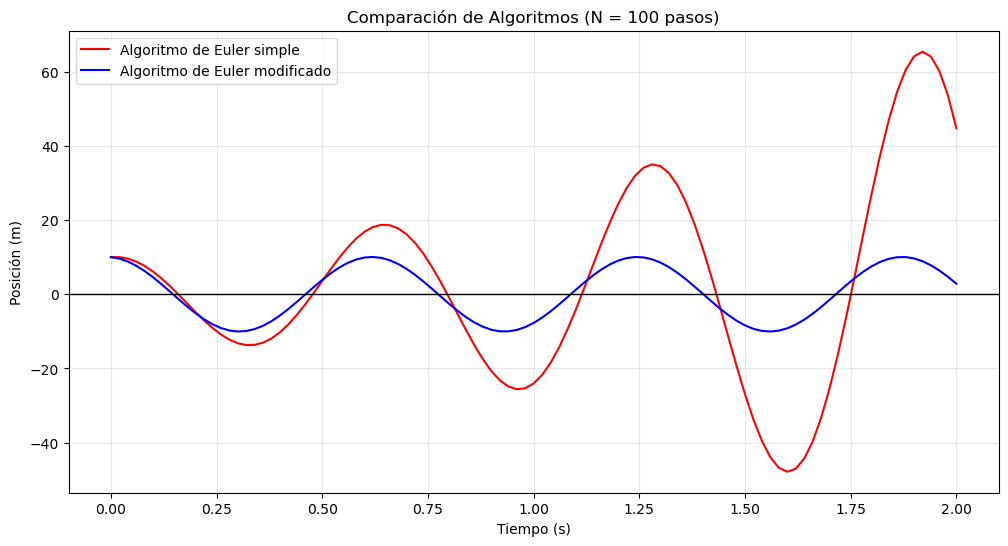

In [12]:
graficar_algoritmos(100)

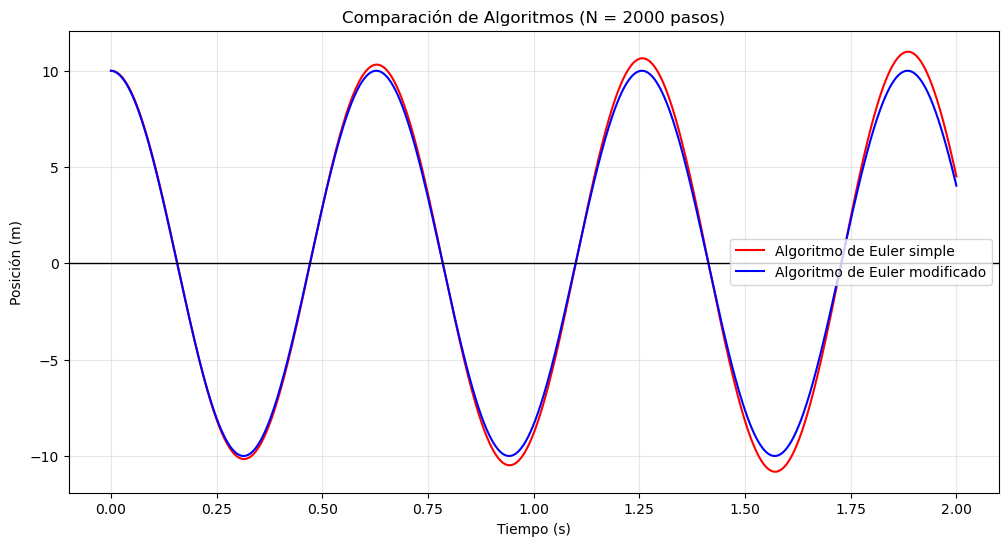

In [13]:
graficar_algoritmos(2000)

#### Conservación de la energía

<p style="text-indent: 0em; text-align: justify;">Podemos comprobar el principio de conservación de la energía de forma computacional. Con $N = 100$ se ven los defectos del Algoritmo de Euler sin modificar.

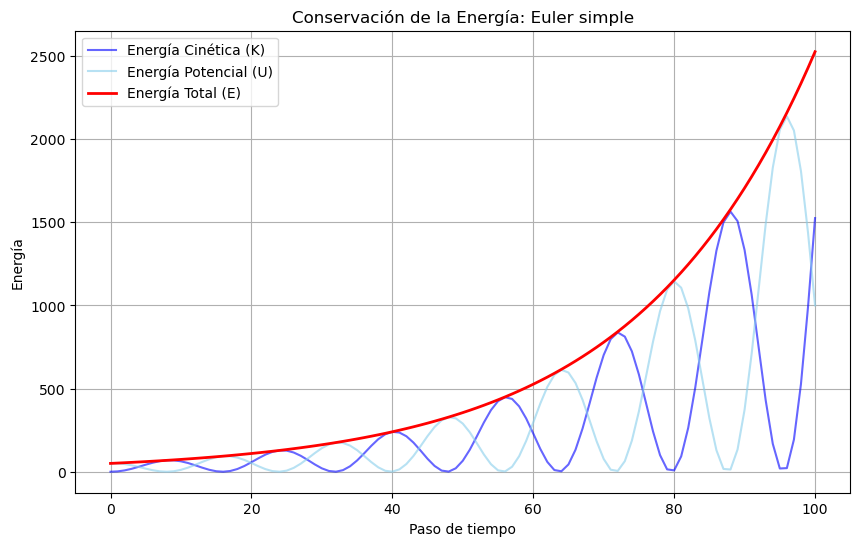

Energía inicial: 50.00000
Energía final:   2525.24741
Diferencia:      2475.24741


In [31]:
posiciones, velocidades = algoritmo_euler(tinicial, tfinal, 100, x0, v0) 
cinetica = [0.5 * masa * v**2 for v in velocidades]
potencial = [0.5 * k * x**2 for x in posiciones]
energia_total = [c + p for c, p in zip(cinetica, potencial)]

plt.figure(figsize=(10, 6))
plt.plot(cinetica, label="Energía Cinética (K)", color='blue', alpha=0.6)
plt.plot(potencial, label="Energía Potencial (U)", color='skyblue', alpha=0.6)
plt.plot(energia_total, label="Energía Total (E)", color='red', linewidth=2)

plt.title("Conservación de la Energía: Euler simple")
plt.xlabel("Paso de tiempo")
plt.ylabel("Energía")
plt.legend()
plt.grid(True)
plt.show()

# Verificación numérica
print(f"Energía inicial: {energia_total[0]:.5f}")
print(f"Energía final:   {energia_total[-1]:.5f}")
print(f"Diferencia:      {abs(energia_total[-1] - energia_total[0]):.5f}")

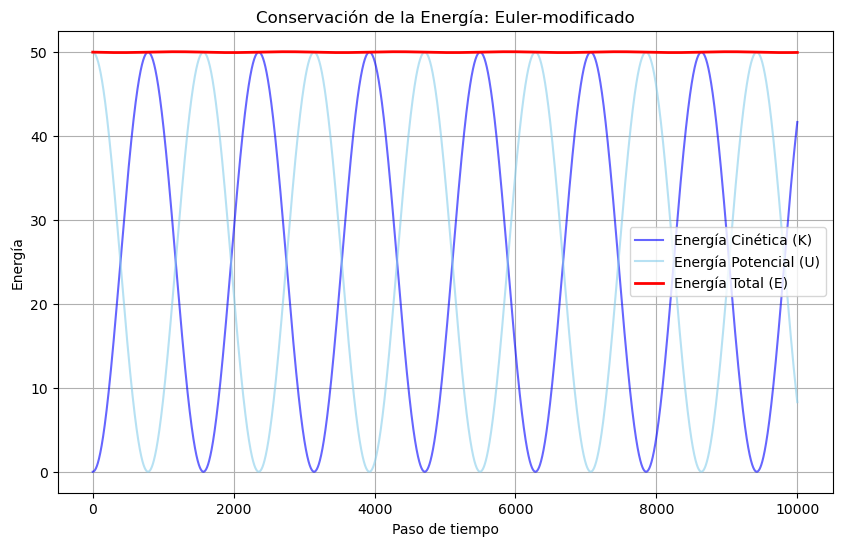

Energía inicial: 50.00000
Energía final:   49.96283
Diferencia:      0.03717


In [33]:
 
posiciones, velocidades = algoritmo_euler_modificado(tinicial, tfinal, 10000, x0, v0) # Aumento la N para que se vea bien la conservación
cinetica = [0.5 * masa * v**2 for v in velocidades]
potencial = [0.5 * k * x**2 for x in posiciones]
energia_total = [c + p for c, p in zip(cinetica, potencial)]

plt.figure(figsize=(10, 6))
plt.plot(cinetica, label="Energía Cinética (K)", color='blue', alpha=0.6)
plt.plot(potencial, label="Energía Potencial (U)", color='skyblue', alpha=0.6)
plt.plot(energia_total, label="Energía Total (E)", color='red', linewidth=2)

plt.title("Conservación de la Energía: Euler-modificado")
plt.xlabel("Paso de tiempo")
plt.ylabel("Energía")
plt.legend()
plt.grid(True)
plt.show()

# Verificación numérica
print(f"Energía inicial: {energia_total[0]:.5f}")
print(f"Energía final:   {energia_total[-1]:.5f}")
print(f"Diferencia:      {abs(energia_total[-1] - energia_total[0]):.5f}")